In [1]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

PROJECT = Path(
    "/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project"
)

DATA_FILE = PROJECT / "data/processed/local_sample.parquet"
CENTRE_FILE = PROJECT / "data/processed/local_coordinate_centre.json"

OUTPUT_DIR = PROJECT / "outputs/integrals_model"
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_FILE.exists()
assert CENTRE_FILE.exists()

local = pd.read_parquet(DATA_FILE)

with CENTRE_FILE.open("r", encoding="utf-8") as handle:
    coordinate_centre = json.load(handle)

coordinate_centre = np.array(
    [
        coordinate_centre["x"],
        coordinate_centre["y"],
        coordinate_centre["z"],
    ],
    dtype=np.float64,
)

print(f"Loaded {len(local):,} stars")
print("Original coordinate centre [kpc]:", coordinate_centre)
print(local["split"].value_counts(sort=False))

Loaded 3,693,480 stars
Original coordinate centre [kpc]: [-8.10838182e+00  3.39357492e-03  5.81829061e-03]
split
train         2585436
validation     554022
test           554022
Name: count, dtype: int64


In [2]:
def add_cylindrical_coordinates(
    frame: pd.DataFrame,
    centre: np.ndarray,
) -> pd.DataFrame:
    output = frame.copy()

    x_global = output["x"].to_numpy(dtype=np.float64) + centre[0]
    y_global = output["y"].to_numpy(dtype=np.float64) + centre[1]
    z_global = output["z"].to_numpy(dtype=np.float64) + centre[2]

    vx = output["vx"].to_numpy(dtype=np.float64)
    vy = output["vy"].to_numpy(dtype=np.float64)
    vz = output["vz"].to_numpy(dtype=np.float64)

    R = np.sqrt(x_global**2 + y_global**2)

    if np.any(R <= 0):
        raise RuntimeError("Encountered R <= 0.")

    v_R = (x_global * vx + y_global * vy) / R
    v_phi = (-y_global * vx + x_global * vy) / R

    output["x_global"] = x_global
    output["y_global"] = y_global
    output["z_global"] = z_global

    output["R"] = R
    output["v_R"] = v_R
    output["v_phi"] = v_phi
    output["v_z_cyl"] = vz

    return output


local_cyl = add_cylindrical_coordinates(
    local,
    coordinate_centre,
)

display(
    local_cyl[
        [
            "R",
            "z_global",
            "v_R",
            "v_phi",
            "v_z_cyl",
        ]
    ].describe()
)

,R,z_global,v_R,v_phi,v_z_cyl
count,3.693480e+06,3.693480e+06,3.693480e+06,3.693480e+06,3.693480e+06
mean,8.111243e+00,5.818291e-03,-2.844368e+00,-2.226894e+02,9.944977e-02
std,2.120331e-01,1.717478e-01,3.828376e+01,2.874911e+01,2.061865e+01
min,7.622104e+00,-4.997360e-01,-7.663105e+02,-9.556981e+02,-6.869947e+02
25%,7.954443e+00,-1.041735e-01,-2.607571e+01,-2.407779e+02,-1.037395e+01
50%,8.110075e+00,9.383349e-03,-2.155349e+00,-2.266261e+02,4.121515e-01
75%,8.265102e+00,1.194270e-01,2.052576e+01,-2.094937e+02,1.103063e+01
max,8.621709e+00,4.995469e-01,7.805853e+02,5.559239e+02,7.390675e+02


In [3]:
TRAIN_QUANTILE_LOW = 0.0025
TRAIN_QUANTILE_HIGH = 0.9975

velocity_columns = [
    "v_R",
    "v_phi",
    "v_z_cyl",
]

train_for_bounds = local_cyl.loc[
    local_cyl["split"] == "train",
    velocity_columns,
]

velocity_lower = (
    train_for_bounds
    .quantile(TRAIN_QUANTILE_LOW)
    .to_numpy(dtype=np.float64)
)

velocity_upper = (
    train_for_bounds
    .quantile(TRAIN_QUANTILE_HIGH)
    .to_numpy(dtype=np.float64)
)

print("Velocity-domain lower limits [km/s]:")
print(dict(zip(velocity_columns, velocity_lower)))

print("\nVelocity-domain upper limits [km/s]:")
print(dict(zip(velocity_columns, velocity_upper)))

inside_velocity_domain = np.ones(
    len(local_cyl),
    dtype=bool,
)

for index, column in enumerate(velocity_columns):
    values = local_cyl[column].to_numpy(dtype=np.float64)

    inside_velocity_domain &= (
        (values >= velocity_lower[index])
        & (values <= velocity_upper[index])
    )

model_data = (
    local_cyl.loc[inside_velocity_domain]
    .reset_index(drop=True)
)

print(f"\nStars before velocity-domain cut: {len(local_cyl):,}")
print(f"Stars after velocity-domain cut:  {len(model_data):,}")
print(
    f"Retained fraction: "
    f"{100 * len(model_data) / len(local_cyl):.3f}%"
)

Velocity-domain lower limits [km/s]:
{'v_R': np.float64(-124.24600509466389), 'v_phi': np.float64(-285.0962811782701), 'v_z_cyl': np.float64(-80.45284499538519)}

Velocity-domain upper limits [km/s]:
{'v_R': np.float64(120.81276004751867), 'v_phi': np.float64(-60.872185267080006), 'v_z_cyl': np.float64(78.95233531075499)}

Stars before velocity-domain cut: 3,693,480
Stars after velocity-domain cut:  3,646,067
Retained fraction: 98.716%


In [4]:
SEED = 20260805

MAX_TRAIN_DATA = 60_000
MAX_VALIDATION_DATA = 30_000

train_data = (
    model_data.loc[
        model_data["split"] == "train"
    ]
    .sample(
        n=min(
            MAX_TRAIN_DATA,
            (
                model_data["split"] == "train"
            ).sum(),
        ),
        random_state=SEED,
        replace=False,
    )
    .reset_index(drop=True)
)

validation_data = (
    model_data.loc[
        model_data["split"] == "validation"
    ]
    .sample(
        n=min(
            MAX_VALIDATION_DATA,
            (
                model_data["split"] == "validation"
            ).sum(),
        ),
        random_state=SEED + 1,
        replace=False,
    )
    .reset_index(drop=True)
)

print(f"Training data stars:   {len(train_data):,}")
print(f"Validation data stars: {len(validation_data):,}")
print("Test stars used:       0")

Training data stars:   60,000
Validation data stars: 30,000
Test stars used:       0


In [5]:
SUN_POSITION_KPC = np.array(
    [-8.122, 0.0, 0.0208],
    dtype=np.float64,
)

R_CUT_KPC = 0.5


def sample_uniform_sphere(
    number: int,
    radius: float,
    rng: np.random.Generator,
) -> np.ndarray:
    directions = rng.normal(
        size=(number, 3)
    )

    directions /= np.linalg.norm(
        directions,
        axis=1,
        keepdims=True,
    )

    radii = radius * rng.random(number) ** (1.0 / 3.0)

    return directions * radii[:, None]


def generate_uniform_reference(
    number: int,
    velocity_lower: np.ndarray,
    velocity_upper: np.ndarray,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    heliocentric_offsets = sample_uniform_sphere(
        number,
        R_CUT_KPC,
        rng,
    )

    global_positions = (
        SUN_POSITION_KPC[None, :]
        + heliocentric_offsets
    )

    v_R, v_phi, v_z = rng.uniform(
        low=velocity_lower,
        high=velocity_upper,
        size=(number, 3),
    ).T

    x_global = global_positions[:, 0]
    y_global = global_positions[:, 1]
    z_global = global_positions[:, 2]

    R = np.sqrt(
        x_global**2 + y_global**2
    )

    cos_phi = x_global / R
    sin_phi = y_global / R

    vx = v_R * cos_phi - v_phi * sin_phi
    vy = v_R * sin_phi + v_phi * cos_phi

    return pd.DataFrame(
        {
            "x_global": x_global,
            "y_global": y_global,
            "z_global": z_global,
            "R": R,
            "v_R": v_R,
            "v_phi": v_phi,
            "v_z_cyl": v_z,
            "vx": vx,
            "vy": vy,
            "vz": v_z,
        }
    )


train_reference = generate_uniform_reference(
    len(train_data),
    velocity_lower,
    velocity_upper,
    seed=SEED + 10,
)

validation_reference = generate_uniform_reference(
    len(validation_data),
    velocity_lower,
    velocity_upper,
    seed=SEED + 11,
)

print("Uniform reference samples generated.")
print("Train reference:", len(train_reference))
print("Validation reference:", len(validation_reference))

Uniform reference samples generated.
Train reference: 60000
Validation reference: 30000


In [6]:
R0_KPC = float(
    np.median(
        train_data["R"].to_numpy(dtype=np.float64)
    )
)


def compute_integrals(
    frame: pd.DataFrame,
    circular_speed_kms: float,
    vertical_frequency_kms_per_kpc: float,
) -> np.ndarray:
    R = frame["R"].to_numpy(dtype=np.float64)
    z = frame["z_global"].to_numpy(dtype=np.float64)

    v_R = frame["v_R"].to_numpy(dtype=np.float64)
    v_phi = frame["v_phi"].to_numpy(dtype=np.float64)
    v_z = frame["v_z_cyl"].to_numpy(dtype=np.float64)

    phi_radial = (
        circular_speed_kms**2
        * np.log(R / R0_KPC)
    )

    phi_vertical = (
        0.5
        * vertical_frequency_kms_per_kpc**2
        * z**2
    )

    E_R = (
        0.5 * (v_R**2 + v_phi**2)
        + phi_radial
    )

    E_z = (
        0.5 * v_z**2
        + phi_vertical
    )

    L_z = R * v_phi

    return np.column_stack(
        [
            E_R,
            E_z,
            L_z,
        ]
    )


print(f"Reference radius R0 = {R0_KPC:.6f} kpc")

Reference radius R0 = 8.111296 kpc


In [7]:
def fit_integral_classifier(
    circular_speed_kms: float,
    vertical_frequency_kms_per_kpc: float,
):
    train_integrals_data = compute_integrals(
        train_data,
        circular_speed_kms,
        vertical_frequency_kms_per_kpc,
    )

    train_integrals_reference = compute_integrals(
        train_reference,
        circular_speed_kms,
        vertical_frequency_kms_per_kpc,
    )

    validation_integrals_data = compute_integrals(
        validation_data,
        circular_speed_kms,
        vertical_frequency_kms_per_kpc,
    )

    validation_integrals_reference = compute_integrals(
        validation_reference,
        circular_speed_kms,
        vertical_frequency_kms_per_kpc,
    )

    scaler = StandardScaler()

    scaler.fit(
        np.vstack(
            [
                train_integrals_data,
                train_integrals_reference,
            ]
        )
    )

    polynomial = PolynomialFeatures(
        degree=2,
        include_bias=False,
    )

    train_integrals_all = np.vstack(
        [
            train_integrals_data,
            train_integrals_reference,
        ]
    )

    validation_integrals_all = np.vstack(
        [
            validation_integrals_data,
            validation_integrals_reference,
        ]
    )

    X_train = polynomial.fit_transform(
        scaler.transform(train_integrals_all)
    )

    X_validation = polynomial.transform(
        scaler.transform(validation_integrals_all)
    )

    y_train = np.concatenate(
        [
            np.ones(len(train_integrals_data)),
            np.zeros(len(train_integrals_reference)),
        ]
    )

    y_validation = np.concatenate(
        [
            np.ones(len(validation_integrals_data)),
            np.zeros(len(validation_integrals_reference)),
        ]
    )

    classifier = LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="lbfgs",
        max_iter=500,
        random_state=SEED,
    )

    classifier.fit(
        X_train,
        y_train,
    )

    validation_probability = (
        classifier.predict_proba(
            X_validation
        )[:, 1]
    )

    validation_prediction = (
        validation_probability >= 0.5
    ).astype(int)

    return {
        "circular_speed_kms": circular_speed_kms,
        "vertical_frequency_kms_per_kpc": (
            vertical_frequency_kms_per_kpc
        ),
        "validation_auc": roc_auc_score(
            y_validation,
            validation_probability,
        ),
        "validation_log_loss": log_loss(
            y_validation,
            validation_probability,
        ),
        "validation_accuracy": accuracy_score(
            y_validation,
            validation_prediction,
        ),
        "classifier": classifier,
        "scaler": scaler,
        "polynomial": polynomial,
        "feature_names": polynomial.get_feature_names_out(
            ["E_R", "E_z", "L_z"]
        ),
    }

In [8]:
CIRCULAR_SPEED_GRID = np.arange(
    180.0,
    261.0,
    10.0,
)

VERTICAL_FREQUENCY_GRID = np.arange(
    40.0,
    111.0,
    10.0,
)

grid_rows = []
grid_models = {}

total_models = (
    len(CIRCULAR_SPEED_GRID)
    * len(VERTICAL_FREQUENCY_GRID)
)

completed = 0
start_time = time.time()

for circular_speed in CIRCULAR_SPEED_GRID:
    for vertical_frequency in VERTICAL_FREQUENCY_GRID:
        result = fit_integral_classifier(
            circular_speed,
            vertical_frequency,
        )

        key = (
            float(circular_speed),
            float(vertical_frequency),
        )

        grid_models[key] = result

        grid_rows.append(
            {
                "circular_speed_kms": circular_speed,
                "vertical_frequency_kms_per_kpc": (
                    vertical_frequency
                ),
                "validation_auc": result[
                    "validation_auc"
                ],
                "validation_log_loss": result[
                    "validation_log_loss"
                ],
                "validation_accuracy": result[
                    "validation_accuracy"
                ],
            }
        )

        completed += 1

        print(
            f"{completed:3d}/{total_models}: "
            f"vc={circular_speed:5.1f}, "
            f"nu={vertical_frequency:5.1f}, "
            f"AUC={result['validation_auc']:.5f}, "
            f"logloss={result['validation_log_loss']:.5f}"
        )

elapsed_minutes = (
    time.time() - start_time
) / 60.0

grid_results = pd.DataFrame(grid_rows)

grid_results = grid_results.sort_values(
    [
        "validation_log_loss",
        "validation_auc",
    ],
    ascending=[True, False],
).reset_index(drop=True)

print(f"\nGrid search completed in {elapsed_minutes:.2f} minutes.")

display(grid_results.head(15))

/ocean/projects/cis240096p/idas/iaifi_summer_school/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


  1/72: vc=180.0, nu= 40.0, AUC=0.94213, logloss=0.30526


/ocean/projects/cis240096p/idas/iaifi_summer_school/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


  2/72: vc=180.0, nu= 50.0, AUC=0.94264, logloss=0.30414


/ocean/projects/cis240096p/idas/iaifi_summer_school/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


...

/ocean/projects/cis240096p/idas/iaifi_summer_school/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


 71/72: vc=260.0, nu=100.0, AUC=0.94396, logloss=0.30084


/ocean/projects/cis240096p/idas/iaifi_summer_school/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


 72/72: vc=260.0, nu=110.0, AUC=0.94327, logloss=0.30258

Grid search completed in 2.05 minutes.


,circular_speed_kms,vertical_frequency_kms_per_kpc,validation_auc,validation_log_loss,validation_accuracy
0,230.0,80.0,0.945806,0.297161,0.877317
1,230.0,70.0,0.945823,0.297312,0.877467
2,240.0,80.0,0.945715,0.297316,0.877433
3,240.0,70.0,0.945735,0.297452,0.877567
4,220.0,80.0,0.945583,0.297504,0.876933
5,230.0,90.0,0.945555,0.297608,0.876933
6,220.0,70.0,0.945641,0.297665,0.877400
7,240.0,90.0,0.945474,0.297754,0.877267
8,230.0,60.0,0.945591,0.297930,0.877450
9,220.0,90.0,0.945369,0.297967,0.876533


In [9]:
best_row = grid_results.iloc[0]

BEST_VC = float(
    best_row["circular_speed_kms"]
)

BEST_NU = float(
    best_row[
        "vertical_frequency_kms_per_kpc"
    ]
)

best_model = grid_models[
    (BEST_VC, BEST_NU)
]

print("BEST VALIDATION MODEL")
print("=" * 60)
print(f"v_c = {BEST_VC:.1f} km/s")
print(f"nu  = {BEST_NU:.1f} km/s/kpc")
print(
    f"Validation AUC: "
    f"{best_model['validation_auc']:.6f}"
)
print(
    f"Validation log loss: "
    f"{best_model['validation_log_loss']:.6f}"
)
print(
    f"Validation accuracy: "
    f"{best_model['validation_accuracy']:.6f}"
)
print("\nAnalytic CBE residual: exactly zero.")

BEST VALIDATION MODEL
v_c = 230.0 km/s
nu  = 80.0 km/s/kpc
Validation AUC: 0.945806
Validation log loss: 0.297161
Validation accuracy: 0.877317

Analytic CBE residual: exactly zero.


In [10]:
classifier = best_model["classifier"]
feature_names = best_model["feature_names"]

coefficients = classifier.coef_[0]
intercept = float(classifier.intercept_[0])

coefficient_table = pd.DataFrame(
    {
        "term": feature_names,
        "coefficient": coefficients,
        "absolute_coefficient": np.abs(coefficients),
    }
).sort_values(
    "absolute_coefficient",
    ascending=False,
)

display(coefficient_table)

print("\nSTANDARDIZATION")
print("=" * 60)

integral_names = ["E_R", "E_z", "L_z"]

for name, mean, scale in zip(
    integral_names,
    best_model["scaler"].mean_,
    best_model["scaler"].scale_,
):
    print(
        f"{name}_standardized = "
        f"({name} - {mean:.12g}) / {scale:.12g}"
    )

print("\nLOG DENSITY RATIO")
print("=" * 60)
print(f"log f = {intercept:.12g}")

for term, coefficient in zip(
    feature_names,
    coefficients,
):
    sign = "+" if coefficient >= 0 else "-"
    print(
        f"    {sign} "
        f"{abs(coefficient):.12g} * {term}"
    )

,term,coefficient,absolute_coefficient
2,L_z,-6.857243,6.857243
0,E_R,-5.120187,5.120187
1,E_z,-1.699788,1.699788
7,E_z L_z,1.533997,1.533997
3,E_R^2,-1.339762,1.339762
4,E_R E_z,0.876157,0.876157
8,L_z^2,0.776815,0.776815
6,E_z^2,0.260737,0.260737
5,E_R L_z,-0.151330,0.151330



STANDARDIZATION
E_R_standardized = (E_R - 22830.94456) / 9633.91063752
E_z_standardized = (E_z - 749.664069347) / 870.166588922
L_z_standardized = (L_z - -1611.13404439) / 449.017783554

LOG DENSITY RATIO
log f = -0.570193648986
    - 5.12018694115 * E_R
    - 1.69978756152 * E_z
    - 6.85724280372 * L_z
    - 1.33976166248 * E_R^2
    + 0.876156976808 * E_R E_z
    - 0.15132999619 * E_R L_z
    + 0.260737428578 * E_z^2
    + 1.53399695242 * E_z L_z
    + 0.776814874192 * L_z^2


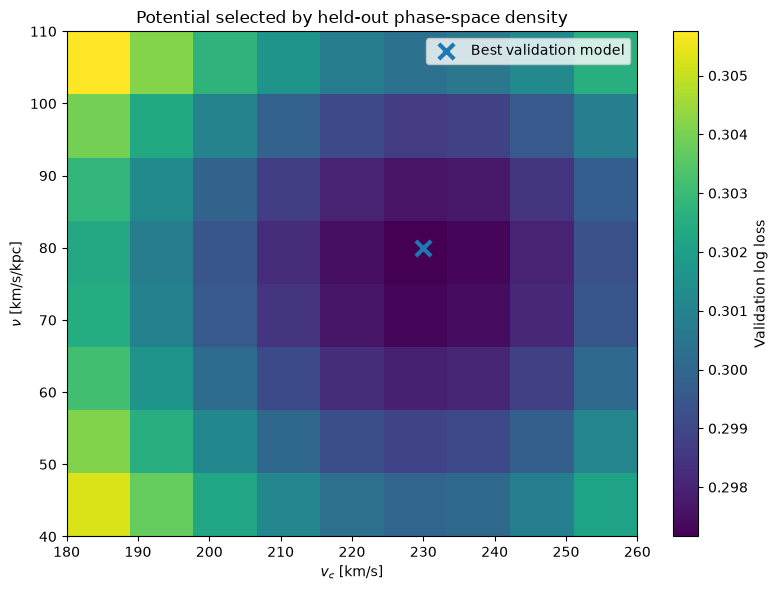

Saved: /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/integrals_model/figures/potential_grid_validation_loss.png


In [11]:
pivot = grid_results.pivot(
    index="vertical_frequency_kms_per_kpc",
    columns="circular_speed_kms",
    values="validation_log_loss",
)

plt.figure(figsize=(8, 6))

image = plt.imshow(
    pivot.to_numpy(),
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
)

plt.colorbar(
    image,
    label="Validation log loss",
)

plt.scatter(
    [BEST_VC],
    [BEST_NU],
    marker="x",
    s=120,
    linewidths=3,
    label="Best validation model",
)

plt.xlabel(r"$v_c$ [km/s]")
plt.ylabel(r"$\nu$ [km/s/kpc]")
plt.title("Potential selected by held-out phase-space density")
plt.legend()
plt.tight_layout()

grid_figure = (
    FIGURE_DIR
    / "potential_grid_validation_loss.png"
)

plt.savefig(
    grid_figure,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", grid_figure)

In [12]:
model_summary = {
    "potential": {
        "expression": (
            "Phi(R,z) = vc^2*log(R/R0) + 0.5*nu^2*z^2"
        ),
        "circular_speed_kms": BEST_VC,
        "vertical_frequency_kms_per_kpc": BEST_NU,
        "R0_kpc": R0_KPC,
    },
    "density": {
        "expression": (
            "f proportional to exp(polynomial(E_R,E_z,L_z))"
        ),
        "integral_names": integral_names,
        "standardization_mean": (
            best_model["scaler"].mean_.tolist()
        ),
        "standardization_scale": (
            best_model["scaler"].scale_.tolist()
        ),
        "polynomial_terms": feature_names.tolist(),
        "coefficients": coefficients.tolist(),
        "intercept": intercept,
    },
    "validation": {
        "auc": float(
            best_model["validation_auc"]
        ),
        "log_loss": float(
            best_model["validation_log_loss"]
        ),
        "accuracy": float(
            best_model["validation_accuracy"]
        ),
        "analytic_cbe_residual": 0.0,
    },
    "test_set_used": False,
}

summary_path = OUTPUT_DIR / "symbolic_model.json"
grid_path = OUTPUT_DIR / "potential_grid.csv"

with summary_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        model_summary,
        handle,
        indent=2,
    )

grid_results.to_csv(
    grid_path,
    index=False,
)

print("INTEGRALS-OF-MOTION MODEL COMPLETE")
print("=" * 60)
print(f"Potential: {model_summary['potential']['expression']}")
print(f"v_c = {BEST_VC:.1f} km/s")
print(f"nu  = {BEST_NU:.1f} km/s/kpc")
print(f"Validation AUC = {best_model['validation_auc']:.6f}")
print(
    f"Validation log loss = "
    f"{best_model['validation_log_loss']:.6f}"
)
print("Analytic CBE residual = 0")
print("Test set used = False")
print("\nSaved:")
print(summary_path)
print(grid_path)

INTEGRALS-OF-MOTION MODEL COMPLETE
Potential: Phi(R,z) = vc^2*log(R/R0) + 0.5*nu^2*z^2
v_c = 230.0 km/s
nu  = 80.0 km/s/kpc
Validation AUC = 0.945806
Validation log loss = 0.297161
Analytic CBE residual = 0
Test set used = False

Saved:
/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/integrals_model/symbolic_model.json
/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/integrals_model/potential_grid.csv


In [13]:
import os

os.environ.setdefault(
    "PYTHON_JULIACALL_THREADS",
    "auto",
)
os.environ.setdefault(
    "PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION",
    "no",
)

from pysr import PySRRegressor
from scipy.special import expit, logsumexp
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
)

PYSR_OUTPUT_DIR = OUTPUT_DIR / "pysr_distillation"
PYSR_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def standardized_integrals(
    frame: pd.DataFrame,
) -> np.ndarray:
    integrals = compute_integrals(
        frame,
        BEST_VC,
        BEST_NU,
    )

    return best_model["scaler"].transform(
        integrals
    )


def dense_teacher_logit(
    standardized_integral_values: np.ndarray,
) -> np.ndarray:
    polynomial_values = (
        best_model["polynomial"].transform(
            standardized_integral_values
        )
    )

    return (
        best_model["classifier"]
        .decision_function(polynomial_values)
    )


Z_train_data = standardized_integrals(
    train_data
)

Z_train_reference = standardized_integrals(
    train_reference
)

Z_validation_data = standardized_integrals(
    validation_data
)

Z_validation_reference = standardized_integrals(
    validation_reference
)

Z_teacher_all = np.vstack(
    [
        Z_train_data,
        Z_train_reference,
    ]
)

teacher_target_all = dense_teacher_logit(
    Z_teacher_all
)

print("Teacher-logit quantiles:")

print(
    np.quantile(
        teacher_target_all,
        [
            0.0,
            0.001,
            0.01,
            0.50,
            0.99,
            0.999,
            1.0,
        ],
    )
)

# Classification probabilities are already saturated
# outside approximately this range.
teacher_target_all = np.clip(
    teacher_target_all,
    -12.0,
    12.0,
)

rng_sr = np.random.default_rng(
    SEED + 100
)

NUMBER_FOR_SYMBOLIC_SEARCH = 40_000

sr_indices = rng_sr.choice(
    len(Z_teacher_all),
    size=min(
        NUMBER_FOR_SYMBOLIC_SEARCH,
        len(Z_teacher_all),
    ),
    replace=False,
)

X_sr = pd.DataFrame(
    Z_teacher_all[sr_indices],
    columns=[
        "eR",
        "eZ",
        "lZ",
    ],
)

y_sr = teacher_target_all[sr_indices]

print(f"PySR training rows: {len(X_sr):,}")
display(X_sr.describe())

Teacher-logit quantiles:
[-13.46196408 -10.37563991  -7.41414997   0.33707268   3.51380594
   3.58713018   3.61897022]
PySR training rows: 40,000


,eR,eZ,lZ
count,40000.000000,40000.000000,40000.000000
mean,0.002661,0.003183,-0.001735
std,1.003474,0.999485,0.999266
min,-2.461103,-0.861512,-1.867607
25%,-0.699525,-0.731129,-0.726431
50%,0.155493,-0.434767,-0.301064
75%,0.712029,0.412043,0.570157
max,2.881121,3.613468,2.535794


In [14]:
sr_model = PySRRegressor(
    niterations=80,
    populations=32,
    population_size=40,
    ncycles_per_iteration=300,

    binary_operators=[
        "+",
        "-",
        "*",
    ],
    unary_operators=[],

    maxsize=17,
    maxdepth=8,

    model_selection="best",

    batching=True,
    batch_size=4096,

    turbo=True,
    precision=32,

    parallelism="multithreading",
    deterministic=False,
    random_state=SEED,

    progress=True,
    verbosity=1,
)

sr_model.fit(
    X_sr,
    y_sr,
)

print(sr_model)

/ocean/projects/cis240096p/idas/iaifi_summer_school/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
/ocean/projects/cis240096p/idas/iaifi_summer_school/.venv/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
   Resolving package versions...
   Installed CpuId ──────────────────────────── v0.3.1
   Installed SIMDTypes ──────────────────────── v0.1.0
   Installed CPUSummary ─────────────────────── v0.2.7
   Installed LayoutPointers ─────────────────── v0.1.17
   Installed BitTwiddlingConvenienceFunctions ─ v0.1.6
   Installed VectorizationBase ──────────────── v0.21.74
   Installed SciMLPublic ────────────────────── v1.2.4
   Installed OffsetArrays ───────────────────── v1.17.0
  

┌ Warning: #= /jet/home/idas/.julia/packages/DynamicExpressions/gNHdy/ext/DynamicExpressionsLoopVectorizationExt.jl:161 =#:
│ `LoopVectorization.check_args` on your inputs failed; running fallback `@inbounds @fastmath` loop instead.
│ Use `warn_check_args=false`, e.g. `@turbo warn_check_args=false ...`, to disable this warning.
└ @ DynamicExpressionsLoopVectorizationExt ~/.julia/packages/LoopVectorization/Y0o9B/src/condense_loopset.jl:1166


Expressions evaluated per second: 1.930e+04
Progress: 607 / 2560 total iterations (23.711%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.968e+00  0.000e+00  y = eR
3           6.191e+00  1.853e-01  y = eR - eZ
5           3.995e+00  2.190e-01  y = (lZ * eR) - eZ
7           2.899e+00  1.604e-01  y = (lZ * (eR + -1.0772)) - eZ
9           1.988e+00  1.887e-01  y = (lZ * (eZ + (eR + -1.3646))) - eZ
11          1.554e+00  1.230e-01  y = (((eR + eZ) * lZ) - (eZ * 1.7555)) - lZ
13          1.108e+00  1.694e-01  y = ((((eR + eZ) + -2.157) * lZ) - eR) - (eZ * 1.6232)
15          1.035e+00  3.382e-02  y = (((lZ + -0.12551) * ((eR + eZ) + -2.2671)) - eR) - (eZ...
                                       * 1.5308)
17          7.964e-01  1.312e-01  y = ((((((eZ + -3.1221) + eR) * lZ) - eR)

┌ Warning: #= /jet/home/idas/.julia/packages/DynamicExpressions/gNHdy/ext/DynamicExpressionsLoopVectorizationExt.jl:187 =#:
│ `LoopVectorization.check_args` on your inputs failed; running fallback `@inbounds @fastmath` loop instead.
│ Use `warn_check_args=false`, e.g. `@turbo warn_check_args=false ...`, to disable this warning.
└ @ DynamicExpressionsLoopVectorizationExt ~/.julia/packages/LoopVectorization/Y0o9B/src/condense_loopset.jl:1166
┌ Warning: #= /jet/home/idas/.julia/packages/DynamicExpressions/gNHdy/ext/DynamicExpressionsLoopVectorizationExt.jl:142 =#:
│ `LoopVectorization.check_args` on your inputs failed; running fallback `@inbounds @fastmath` loop instead.
│ Use `warn_check_args=false`, e.g. `@turbo warn_check_args=false ...`, to disable this warning.
└ @ DynamicExpressionsLoopVectorizationExt ~/.julia/packages/LoopVectorization/Y0o9B/src/condense_loopset.jl:1166
┌ Warning: #= /jet/home/idas/.julia/packages/DynamicExpressions/gNHdy/ext/DynamicExpressionsLoopVectorizationExt

PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                                 eR   
	1        0.185293                                            eR - eZ   
	2        0.218969                                     (lZ * eR) - eZ   
	3        0.160498                      (lZ * (eR + -1.0390879)) - eZ   
	4        0.188597                ((eR + (eZ + -1.365554)) * lZ) - eZ   
	5        0.134430        (((eR + (eZ + -2.1569881)) * lZ) - eR) - eZ   
	6  >>>>  0.157895  ((((eR + eZ) + -2.1569881) * lZ) - eR) - (eZ *...   
	7        0.141270  (((((eZ + -3.122077) + eR) * lZ) - eR) - (eZ *...   
	8        0.023720  ((((((eZ + -3.122077) + eR) * lZ) - eR) - (eZ ...   
	
	       loss  complexity  
	0  8.967698           1  
	1  6.190667           3  
	2  3.995248           5  
	3  2.898259           7  
	4  1.987575           9  
	5  1.519006          11  
	6  1.107677          13  
	7  0.835040          1

In [15]:
X_validation_sr = pd.DataFrame(
    np.vstack(
        [
            Z_validation_data,
            Z_validation_reference,
        ]
    ),
    columns=[
        "eR",
        "eZ",
        "lZ",
    ],
)

y_validation_binary = np.concatenate(
    [
        np.ones(
            len(Z_validation_data),
            dtype=np.int64,
        ),
        np.zeros(
            len(Z_validation_reference),
            dtype=np.int64,
        ),
    ]
)

teacher_validation_logit = dense_teacher_logit(
    X_validation_sr.to_numpy()
)

teacher_validation_probability = expit(
    np.clip(
        teacher_validation_logit,
        -50.0,
        50.0,
    )
)

teacher_validation_log_loss = log_loss(
    y_validation_binary,
    teacher_validation_probability,
)

teacher_validation_auc = roc_auc_score(
    y_validation_binary,
    teacher_validation_probability,
)

print("Dense teacher validation metrics")
print(
    f"log loss = "
    f"{teacher_validation_log_loss:.6f}"
)
print(
    f"AUC      = "
    f"{teacher_validation_auc:.6f}"
)

Dense teacher validation metrics
log loss = 0.297161
AUC      = 0.945806


In [16]:
spatial_volume = (
    4.0
    / 3.0
    * np.pi
    * R_CUT_KPC**3
)

velocity_volume = float(
    np.prod(
        velocity_upper
        - velocity_lower
    )
)

log_phase_space_volume = np.log(
    spatial_volume
    * velocity_volume
)


def normalized_density_nll(
    data_log_density: np.ndarray,
    reference_log_density: np.ndarray,
) -> float:
    log_normalization = (
        log_phase_space_volume
        + logsumexp(
            reference_log_density
        )
        - np.log(
            len(reference_log_density)
        )
    )

    return float(
        -np.mean(data_log_density)
        + log_normalization
    )


number_validation_data = len(
    Z_validation_data
)

teacher_validation_nll = normalized_density_nll(
    teacher_validation_logit[
        :number_validation_data
    ],
    teacher_validation_logit[
        number_validation_data:
    ],
)

print(
    f"Teacher normalized validation NLL = "
    f"{teacher_validation_nll:.6f}"
)

Teacher normalized validation NLL = 13.236009


In [17]:
symbolic_rows = []

for equation_index, equation_row in (
    sr_model.equations_.iterrows()
):
    try:
        symbolic_logit = np.asarray(
            sr_model.predict(
                X_validation_sr,
                index=equation_index,
            )
        ).reshape(-1)

    except Exception as error:
        print(
            f"Skipping equation "
            f"{equation_index}: {error}"
        )
        continue

    if not np.isfinite(
        symbolic_logit
    ).all():
        continue

    symbolic_probability = expit(
        np.clip(
            symbolic_logit,
            -50.0,
            50.0,
        )
    )

    symbolic_prediction = (
        symbolic_probability >= 0.5
    ).astype(np.int64)

    symbolic_nll = normalized_density_nll(
        symbolic_logit[
            :number_validation_data
        ],
        symbolic_logit[
            number_validation_data:
        ],
    )

    symbolic_rows.append(
        {
            "equation_index": int(
                equation_index
            ),
            "complexity": int(
                equation_row["complexity"]
            ),
            "equation": str(
                equation_row["equation"]
            ),
            "teacher_mse": float(
                np.mean(
                    (
                        symbolic_logit
                        - teacher_validation_logit
                    ) ** 2
                )
            ),
            "validation_log_loss": float(
                log_loss(
                    y_validation_binary,
                    symbolic_probability,
                )
            ),
            "validation_auc": float(
                roc_auc_score(
                    y_validation_binary,
                    symbolic_probability,
                )
            ),
            "validation_accuracy": float(
                accuracy_score(
                    y_validation_binary,
                    symbolic_prediction,
                )
            ),
            "normalized_validation_nll": (
                symbolic_nll
            ),
        }
    )

symbolic_comparison = pd.DataFrame(
    symbolic_rows
).sort_values(
    [
        "complexity",
        "validation_log_loss",
    ]
).reset_index(drop=True)

display(symbolic_comparison)

,equation_index,complexity,equation,teacher_mse,validation_log_loss,validation_auc,validation_accuracy,normalized_validation_nll
0,0,1,eR,8.711396,0.643884,0.684148,0.682900,15.431114
1,1,3,eR - eZ,5.988674,0.503186,0.824340,0.796867,14.815915
2,2,5,(lZ * eR) - eZ,3.954851,0.476014,0.887189,0.777933,14.252538
3,3,7,(lZ * (eR + -1.0390879)) - eZ,2.811957,0.393759,0.928369,0.856917,13.926770
4,4,9,((eR + (eZ + -1.365554)) * lZ) - eZ,1.930013,0.374771,0.917134,0.842267,13.845695
5,5,11,(((eR + (eZ + -2.1569881)) * lZ) - eR) - eZ,1.487683,0.349685,0.934520,0.861317,13.662321
6,6,13,((((eR + eZ) + -2.1569881) * lZ) - eR) - (eZ *...,1.096091,0.338107,0.933117,0.857017,13.581286
7,7,15,(((((eZ + -3.122077) + eR) * lZ) - eR) - (eZ *...,0.836369,0.322684,0.939812,0.866350,13.467405
8,8,17,((((((eZ + -3.122077) + eR) * lZ) - eR) - (eZ ...,0.791481,0.323592,0.939812,0.862550,13.467405


In [18]:
comparison_file = (
    PYSR_OUTPUT_DIR
    / "symbolic_validation_comparison.csv"
)

equations_file = (
    PYSR_OUTPUT_DIR
    / "pysr_equations.csv"
)

symbolic_comparison.to_csv(
    comparison_file,
    index=False,
)

sr_model.equations_.to_csv(
    equations_file,
    index=True,
)

print("PYSR DISTILLATION COMPLETE")
print("=" * 60)

print(
    f"Dense-teacher validation log loss: "
    f"{teacher_validation_log_loss:.6f}"
)

print(
    f"Dense-teacher normalized NLL: "
    f"{teacher_validation_nll:.6f}"
)

print("\nSaved:")
print(comparison_file)
print(equations_file)

print("\nTest set used: False")

PYSR DISTILLATION COMPLETE
Dense-teacher validation log loss: 0.297161
Dense-teacher normalized NLL: 13.236009

Saved:
/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/integrals_model/pysr_distillation/symbolic_validation_comparison.csv
/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/integrals_model/pysr_distillation/pysr_equations.csv

Test set used: False


In [19]:
SELECTED_EQUATION_INDEX = 7
MAX_TEST_DATA = 100_000

selected_equation = str(
    sr_model.equations_.loc[
        SELECTED_EQUATION_INDEX,
        "equation",
    ]
)

print("FROZEN SYMBOLIC EQUATION")
print(selected_equation)

test_pool = model_data.loc[
    model_data["split"] == "test"
]

test_data = (
    test_pool.sample(
        n=min(MAX_TEST_DATA, len(test_pool)),
        random_state=SEED + 200,
        replace=False,
    )
    .reset_index(drop=True)
)

test_reference = generate_uniform_reference(
    len(test_data),
    velocity_lower,
    velocity_upper,
    seed=SEED + 201,
)

Z_test_data = standardized_integrals(test_data)
Z_test_reference = standardized_integrals(test_reference)

X_test_sr = pd.DataFrame(
    np.vstack([
        Z_test_data,
        Z_test_reference,
    ]),
    columns=["eR", "eZ", "lZ"],
)

y_test = np.concatenate([
    np.ones(len(test_data), dtype=np.int64),
    np.zeros(len(test_reference), dtype=np.int64),
])

teacher_test_logit = dense_teacher_logit(
    X_test_sr.to_numpy()
)

symbolic_test_logit = np.asarray(
    sr_model.predict(
        X_test_sr,
        index=SELECTED_EQUATION_INDEX,
    )
).reshape(-1)

teacher_probability = expit(
    np.clip(teacher_test_logit, -50, 50)
)

symbolic_probability = expit(
    np.clip(symbolic_test_logit, -50, 50)
)

number_test_data = len(test_data)

teacher_test_nll = normalized_density_nll(
    teacher_test_logit[:number_test_data],
    teacher_test_logit[number_test_data:],
)

symbolic_test_nll = normalized_density_nll(
    symbolic_test_logit[:number_test_data],
    symbolic_test_logit[number_test_data:],
)

final_results = {
    "selected_equation_index": SELECTED_EQUATION_INDEX,
    "complexity": int(
        sr_model.equations_.loc[
            SELECTED_EQUATION_INDEX,
            "complexity",
        ]
    ),
    "equation": selected_equation,
    "test_stars": len(test_data),
    "teacher_test_log_loss": float(
        log_loss(y_test, teacher_probability)
    ),
    "teacher_test_auc": float(
        roc_auc_score(y_test, teacher_probability)
    ),
    "teacher_test_nll": teacher_test_nll,
    "symbolic_test_log_loss": float(
        log_loss(y_test, symbolic_probability)
    ),
    "symbolic_test_auc": float(
        roc_auc_score(y_test, symbolic_probability)
    ),
    "symbolic_test_accuracy": float(
        accuracy_score(
            y_test,
            symbolic_probability >= 0.5,
        )
    ),
    "symbolic_test_nll": symbolic_test_nll,
    "analytic_cbe_residual": 0.0,
}

final_path = OUTPUT_DIR / "final_test_results.json"

with final_path.open("w", encoding="utf-8") as handle:
    json.dump(final_results, handle, indent=2)

print("\nFINAL UNTOUCHED TEST RESULTS")
print("=" * 60)

for key, value in final_results.items():
    print(f"{key}: {value}")

print("\nSaved:", final_path)

FROZEN SYMBOLIC EQUATION
(((((eZ + -3.122077) + eR) * lZ) - eR) - (eZ * 1.5996432)) - eR

FINAL UNTOUCHED TEST RESULTS
selected_equation_index: 7
complexity: 15
equation: (((((eZ + -3.122077) + eR) * lZ) - eR) - (eZ * 1.5996432)) - eR
test_stars: 100000
teacher_test_log_loss: 0.296357737325232
teacher_test_auc: 0.9462064011000001
teacher_test_nll: 13.227428092575508
symbolic_test_log_loss: 0.32160193570494555
symbolic_test_auc: 0.9405691666000001
symbolic_test_accuracy: 0.86553
symbolic_test_nll: 13.460374423392292
analytic_cbe_residual: 0.0

Saved: /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/integrals_model/final_test_results.json
